In [9]:
from __future__ import annotations
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().parent.resolve()
RAW_DATA_DIR = ROOT / "data" / "raw"
wltp_file = RAW_DATA_DIR / "MLP001_wltp_25degC.xlsx"

In [ ]:
# open file using pd read xlsx
df = pd.read_excel(wltp_file, engine="openpyxl", sheet_name="record")
# openpyxl supports newer excel formats.

/Users/williambuesnel/anaconda3/envs/FuseProject/lib/python3.14/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
print(f"Dataframe shape: {df.shape}")
print(f"Dataframe columns: {df.columns.tolist()}")
print(f"Dataframe head:\n{df.head()}")

Dataframe shape: (395302, 14)
Dataframe columns: ['DataPoint', 'Step Type', 'Time', 'Total Time', 'Current(A)', 'Voltage(V)', 'Capacity(Ah)', 'Energy(Wh)', 'Date', 'Power(W)', 'V1(V)', 'T1(℃)', 'Aux. ΔV(V)', 'Aux. ΔT(℃)']
Dataframe head:
   DataPoint Step Type      Time Total Time  Current(A)  Voltage(V)  \
0          1      Rest  00:00:00   00:00:00         0.0      4.1715   
1          2      Rest  00:00:00   00:00:00         0.0      4.1715   
2          3      Rest  00:00:00   00:00:00         0.0      4.1716   
3          4      Rest  00:00:00   00:00:00         0.0      4.1715   
4          5      Rest  00:00:00   00:00:00         0.0      4.1715   

   Capacity(Ah)  Energy(Wh)                 Date  Power(W)  V1(V)  T1(℃)  \
0           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.9   
1           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.7   
2           0.0         0.0  2024-10-07 09:09:47       0.0      0   23.7   
3           0.0         0.0  20

<Axes: xlabel='Voltage(V)', ylabel='Count'>

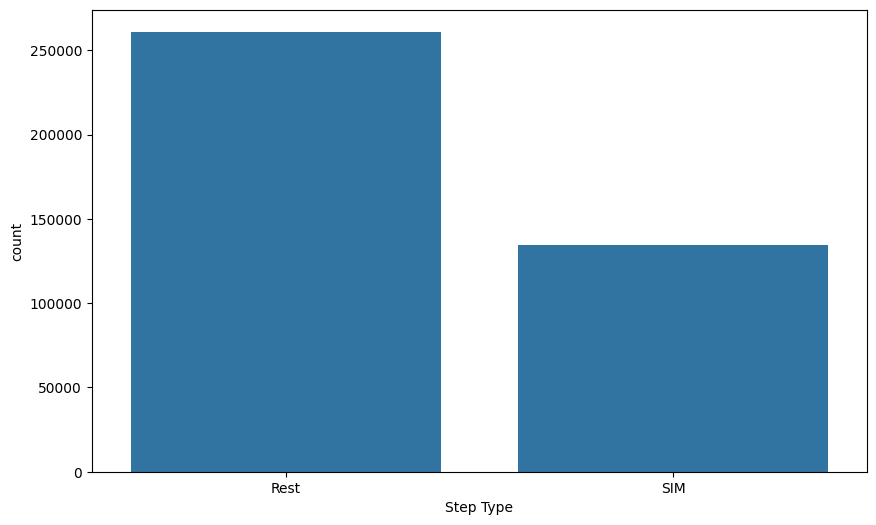

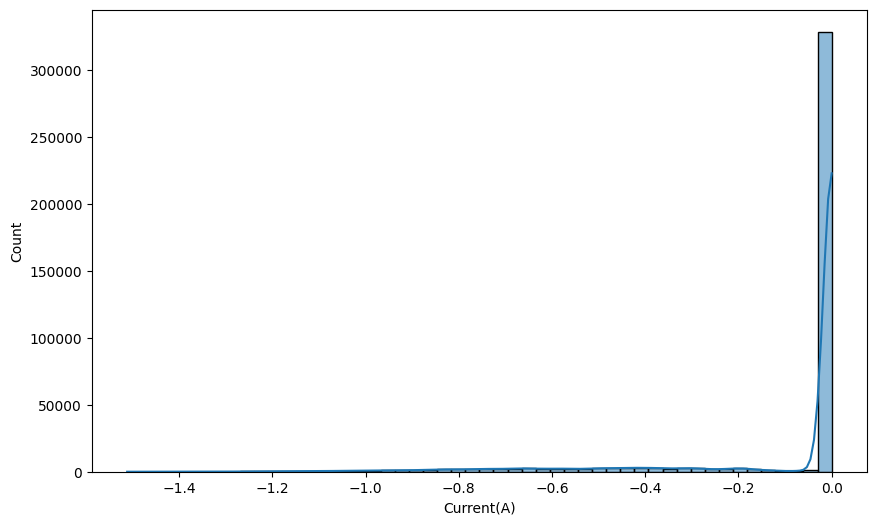

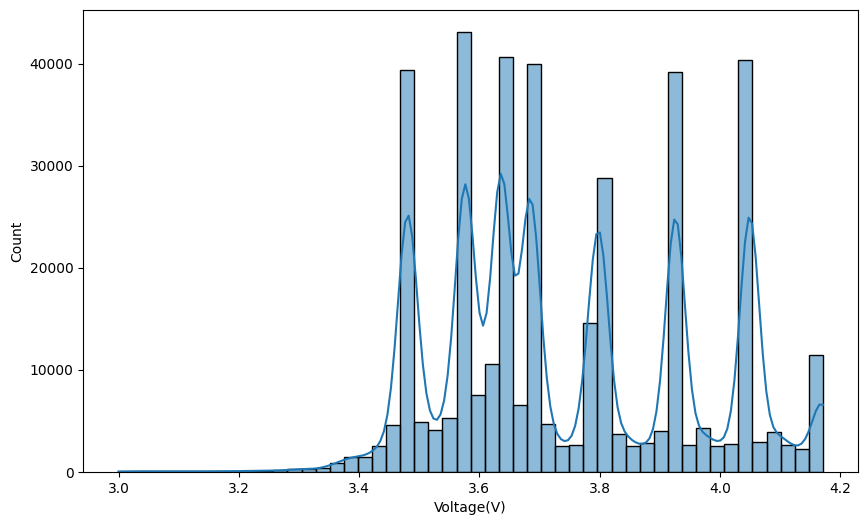

In [21]:
# plot distribution of columns using seaborn
# will do this individually for more control

# first plot distribution of 'Step Type' col (which is categorical)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Step Type')
plt.figure(figsize=(10, 6))
# then we will plot histogram distr. of current, 
sns.histplot(data=df, x='Current(A)', bins=50, kde=True)

# same as above for voltage
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Voltage(V)', bins=50, kde=True)


In [25]:
# see when the first non-zero current occurs, and when the last non-zero current occurs
first_non_zero_current = df[df['Current(A)'] != 0].iloc[0]
last_non_zero_current = df[df['Current(A)'] != 0].iloc[-1]
print(f"First non-zero current occurs at time: {first_non_zero_current['Time']}, value: {first_non_zero_current['Current(A)']}")
print(f"Last non-zero current occurs at time: {last_non_zero_current['Time']}, value: {last_non_zero_current['Current(A)']}")
indexes = df[df['Current(A)'] != 0].index
print(f"Indexes of non-zero current values: {list(indexes)}")
print(f"Indexes of first and last non-zero current values: {indexes[0]}, {indexes[-1]}")

First non-zero current occurs at time: 00:00:12, value: -0.0383344
Last non-zero current occurs at time: 00:27:37, value: -1.1466478
Indexes of non-zero current values: [9062, 9063, 9064, 9065, 9066, 9067, 9068, 9069, 9070, 9071, 9072, 9073, 9074, 9075, 9076, 9077, 9078, 9079, 9080, 9081, 9082, 9083, 9084, 9085, 9086, 9087, 9088, 9089, 9090, 9091, 9092, 9093, 9094, 9095, 9096, 9097, 9098, 9099, 9100, 9101, 9102, 9103, 9104, 9105, 9106, 9107, 9108, 9109, 9110, 9111, 9112, 9113, 9114, 9115, 9116, 9117, 9118, 9119, 9120, 9121, 9122, 9123, 9124, 9125, 9126, 9127, 9128, 9129, 9130, 9131, 9132, 9133, 9134, 9135, 9136, 9137, 9138, 9139, 9140, 9141, 9142, 9143, 9144, 9145, 9146, 9147, 9148, 9149, 9150, 9151, 9152, 9153, 9154, 9155, 9156, 9157, 9158, 9159, 9160, 9161, 9162, 9163, 9164, 9165, 9166, 9167, 9168, 9169, 9170, 9171, 9172, 9173, 9174, 9175, 9176, 9247, 9248, 9249, 9250, 9251, 9277, 9278, 9279, 9280, 9281, 9282, 9283, 9284, 9285, 9286, 9287, 9288, 9289, 9290, 9291, 9292, 9293, 9294, 92

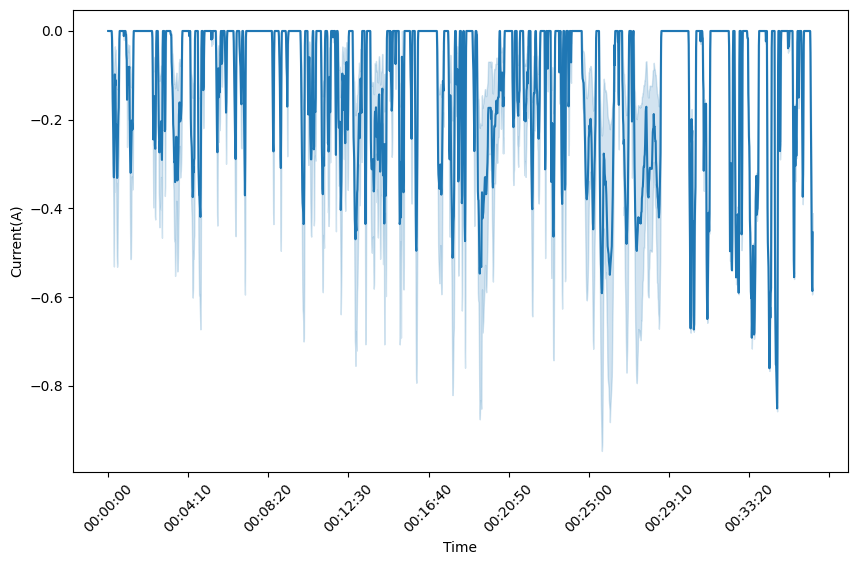

In [27]:
# now just plot current over time, to see how it changes over the course of the test
# change the df to just select the first 20,000 rows, to make the plot more readable
df = df.iloc[:20000]
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time', y='Current(A)')
# clean up xticks and decrease the amount of them, to make the plot more readable
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))

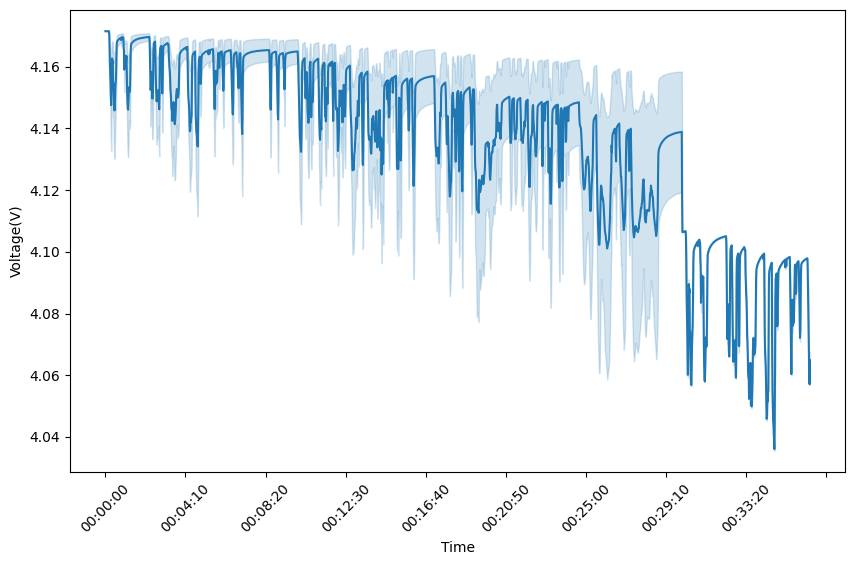

In [28]:
# do the same as above for voltage,
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Time', y='Voltage(V)')
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(nbins=10))
